# Factor Analysis: Building a Marginalization Index for Mexico

How do you measure something you can't observe directly — like "marginalization"?

You can't walk into a state and read off a single number. But you *can* measure many correlated
symptoms: illiteracy rates, lack of running water, overcrowded housing, low incomes.
**Factor Analysis** is the statistical tool that takes a set of correlated observed variables
and asks: what underlying *latent factor* is driving all of them?

In this tutorial we apply Factor Analysis to CONAPO's marginalization indicators across
Mexico's 32 states. The result is a single composite score — an **Index of Marginalization**
— that ranks states from most to least deprived, and tells us *which* deprivations matter most.

**What you'll learn:**
- How Factor Analysis differs from PCA and when to use each
- How to test whether your data is suitable for Factor Analysis (Bartlett + KMO)
- How to choose the number of factors using eigenvalues and the scree plot
- How to interpret factor loadings and communalities
- What rotation does — and why it's less relevant with a single factor

**Data source:** CONAPO (Consejo Nacional de Población) — marginalization indicators
by state, based on INEGI census data. 32 states × 9 indicators.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

## The Dataset: CONAPO Marginalization Indicators

CONAPO constructs its marginalization index from nine indicators, each measuring the
**percentage of the population that lacks** a basic good or service. Higher values mean
more deprivation — unlike the previous household consumption notebook where higher meant better.

| Code | Indicator |
|------|-----------|
| A | % Population aged 15+ who are illiterate |
| B | % Population aged 15+ without completed primary school |
| C | % Households without sewage or toilet |
| D | % Households without electricity |
| E | % Households without running water |
| F | % Households with overcrowding |
| G | % Households with dirt floors |
| H | % Population in localities with fewer than 5,000 inhabitants (rural) |
| I | % Employed population earning ≤ 2 minimum wages |

These indicators cluster into three thematic groups: **education deprivation** (A, B),
**housing infrastructure** (C, D, E, F, G), and **economic/geographic marginality** (H, I).

In [2]:
df = pd.read_excel('pobreza.xlsx')
df.columns = ['estado'] + list('ABCDEFGHI')
df['estado'] = df['estado'].str.strip()

VARS = list('ABCDEFGHI')
LABELS = {
    'A': 'Analfabetismo',   'B': 'Sin primaria',
    'C': 'Sin drenaje',     'D': 'Sin electricidad',
    'E': 'Sin agua',        'F': 'Hacinamiento',
    'G': 'Piso de tierra',  'H': 'Población rural',
    'I': 'Bajo ingreso'
}
GROUPS = {
    'Educación'       : ['A', 'B'],
    'Infraestructura' : ['C', 'D', 'E', 'F', 'G'],
    'Económico/Geog.' : ['H', 'I'],
}
GROUP_COLORS = {'Educación': '#e07b54', 'Infraestructura': '#5b8db8', 'Económico/Geog.': '#6ab187'}

print(f"Dataset: {df.shape[0]} states × {len(VARS)} indicators")
df.head()

Dataset: 32 states × 9 indicators


,estado,A,B,C,D,E,F,G,H,I
0,Aguascalientes,2.60,11.89,0.67,0.30,0.81,21.86,0.75,25.16,34.60
1,Baja California,1.96,10.46,0.26,0.47,2.82,23.03,1.15,10.35,22.85
2,Baja California Sur,2.51,11.59,0.38,1.14,7.15,26.23,4.08,15.64,22.37
3,Campeche,6.68,18.56,4.08,1.59,6.49,37.93,2.95,30.88,40.69
4,Coahulia de Zaragoza,1.99,9.56,0.62,0.29,1.67,23.62,0.66,12.15,27.94


## Exploratory Analysis

### Which states have the highest overall deprivation?

Let's start with a dot plot — each point is a state, each panel is an indicator.
We're looking for states that consistently appear at the top (highest deprivation)
across multiple indicators.

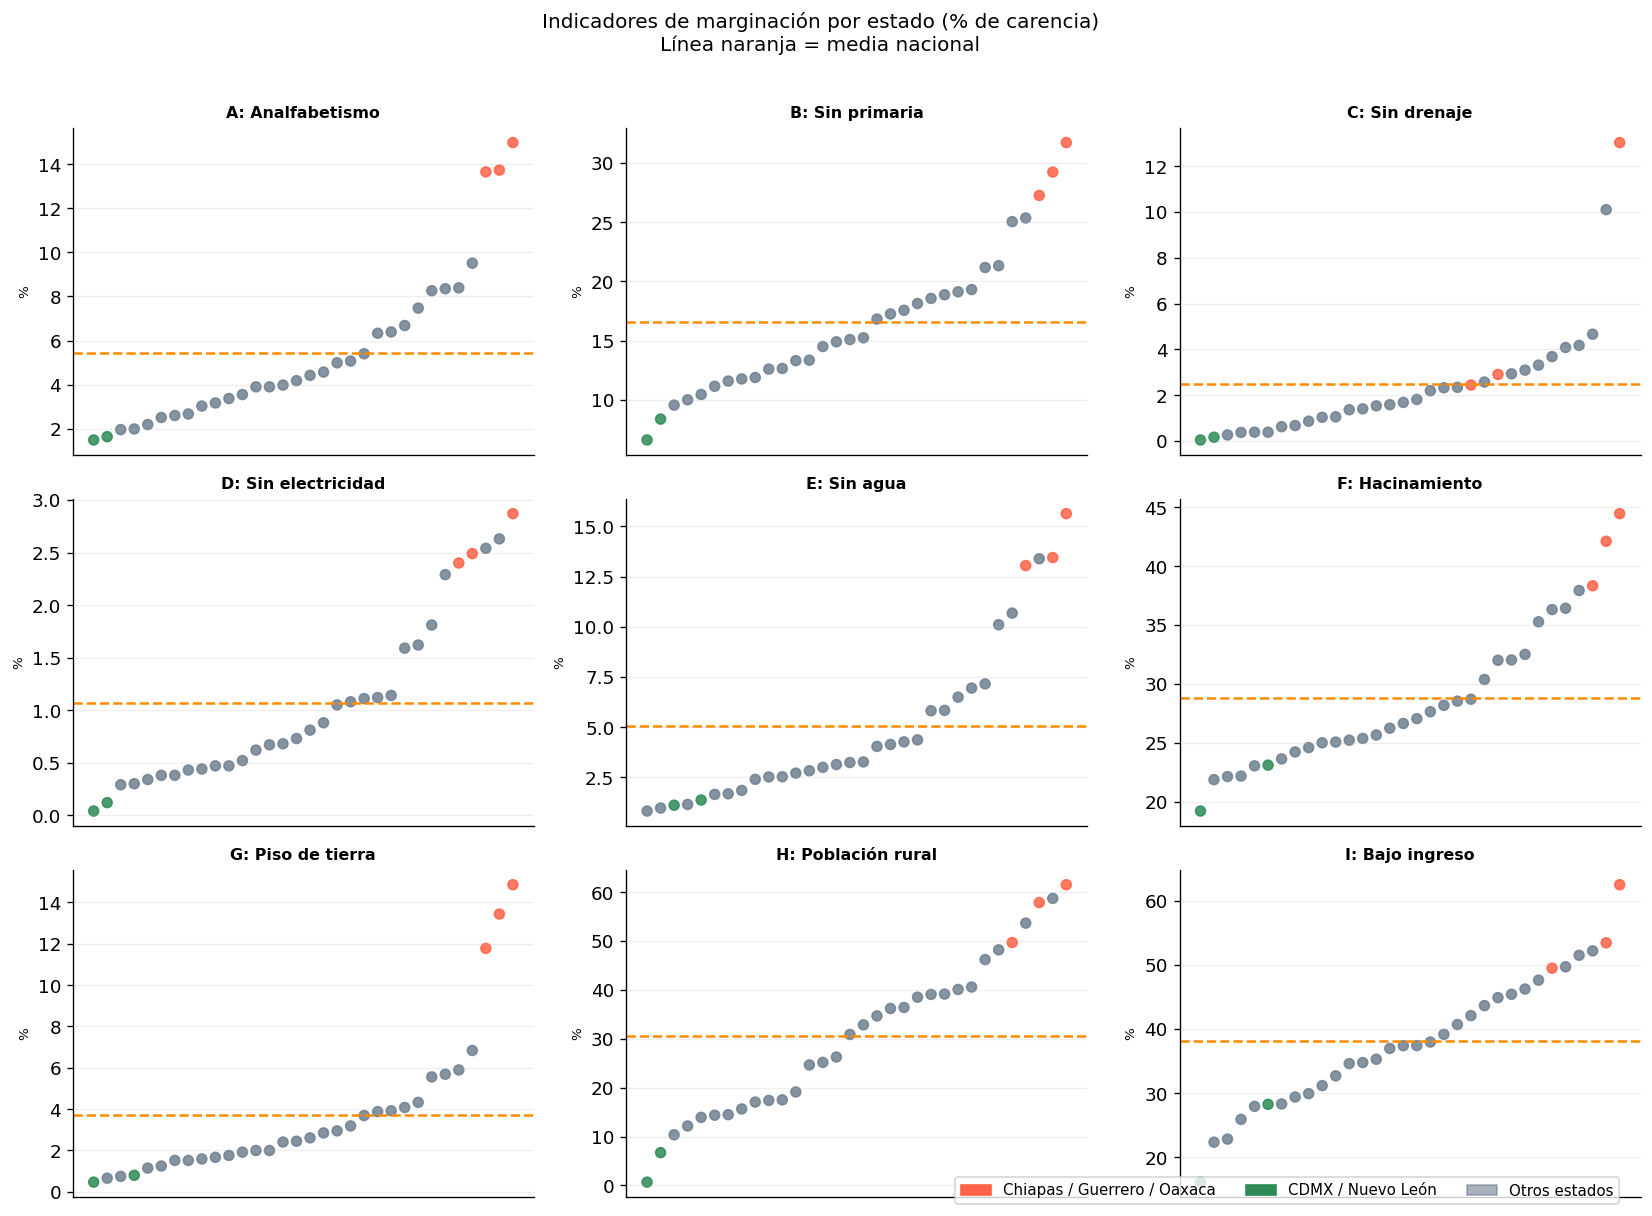

In [3]:
df_long = df.melt(id_vars='estado', value_vars=VARS,
                  var_name='indicator', value_name='pct')
df_long['label'] = df_long['indicator'].map(LABELS)

HIGHLIGHT = {
    'Chiapas': 'tomato', 'Guerrero': 'tomato', 'Oaxaca': 'tomato',
    'Cuidad de México': 'seagreen', 'Nuevo Leon': 'seagreen',
}

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(VARS):
    ax = axes[i]
    sub = df_long[df_long['indicator'] == var].sort_values('pct')
    colors = [HIGHLIGHT.get(s, 'slategrey') for s in sub['estado']]
    ax.scatter(range(len(sub)), sub['pct'], c=colors, s=35, alpha=0.85)
    ax.axhline(sub['pct'].mean(), color='darkorange', linewidth=1.5, linestyle='--')
    ax.set_title(f'{var}: {LABELS[var]}', fontweight='bold', fontsize=9.5)
    ax.set_ylabel('%', fontsize=8)
    ax.set_xticks([])
    ax.grid(True, alpha=0.2)

legend_elements = [
    mpatches.Patch(color='tomato',    label='Chiapas / Guerrero / Oaxaca'),
    mpatches.Patch(color='seagreen',  label='CDMX / Nuevo León'),
    mpatches.Patch(color='slategrey', alpha=0.6, label='Otros estados'),
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=9, ncol=3,
           bbox_to_anchor=(0.98, 0.01))
plt.suptitle('Indicadores de marginación por estado (% de carencia)\nLínea naranja = media nacional',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

Chiapas, Guerrero, and Oaxaca appear at the top of virtually every indicator — confirming
they are structurally marginalized across education, housing, and income dimensions.
Nuevo León and CDMX consistently sit at the bottom (lowest deprivation).

Notice also that the indicators have very different *scales*: illiteracy (A) goes up to 15%
while rural population (H) reaches 62%. This makes standardization essential before
running Factor Analysis.

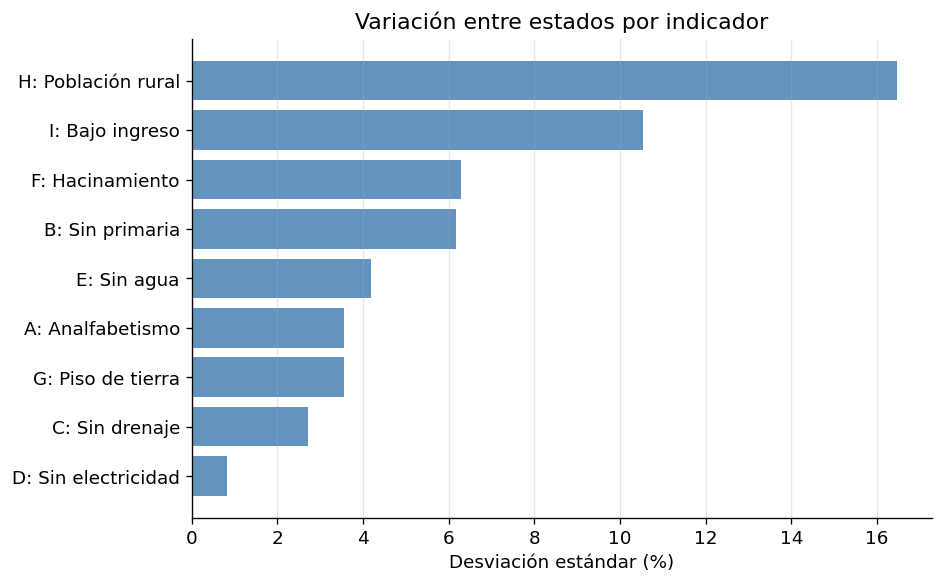

                     Media (%)  Desv. Estándar
D: Sin electricidad       1.07            0.83
C: Sin drenaje            2.47            2.73
G: Piso de tierra         3.73            3.56
A: Analfabetismo          5.45            3.57
E: Sin agua               5.04            4.19
B: Sin primaria          16.55            6.17
F: Hacinamiento          28.77            6.30
I: Bajo ingreso          38.05           10.53
H: Población rural       30.61           16.47


In [4]:
# Summary: mean and std by indicator
stats_df = df[VARS].agg(['mean', 'std']).T
stats_df.columns = ['Media (%)', 'Desv. Estándar']
stats_df.index = [f'{v}: {LABELS[v]}' for v in VARS]
stats_df = stats_df.sort_values('Desv. Estándar', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(stats_df.index, stats_df['Desv. Estándar'], color='steelblue', alpha=0.85)
ax.set_xlabel('Desviación estándar (%)')
ax.set_title('Variación entre estados por indicador')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(stats_df.round(2).to_string())

## Normality Tests

Factor Analysis (particularly the Maximum Likelihood method) assumes variables are
approximately normally distributed. We test each indicator with the **Shapiro-Wilk** test:

- H₀: the variable follows a normal distribution
- Reject H₀ if p < 0.05

> **Note:** The original analysis had a copy-paste error — indicator E was tested using
> the data from indicator A. The correct results are shown below.

In [5]:
print(f"{'Var':<4} {'Indicator':<22} {'W statistic':>12} {'p-value':>10} {'Result':>15}")
print("-" * 68)

for v in VARS:
    stat, p = stats.shapiro(df[v])
    result = "Normal ✓" if p > 0.05 else "Not normal ✗"
    print(f"{v:<4} {LABELS[v]:<22} {stat:>12.4f} {p:>10.4f} {result:>15}")

Var  Indicator               W statistic    p-value          Result
--------------------------------------------------------------------
A    Analfabetismo                0.8563     0.0006    Not normal ✗
B    Sin primaria                 0.9484     0.1296        Normal ✓
C    Sin drenaje                  0.7096     0.0000    Not normal ✗
D    Sin electricidad             0.8710     0.0012    Not normal ✗
E    Sin agua                     0.8306     0.0002    Not normal ✗
F    Hacinamiento                 0.9214     0.0228    Not normal ✗
G    Piso de tierra               0.7492     0.0000    Not normal ✗
H    Población rural              0.9626     0.3236        Normal ✓
I    Bajo ingreso                 0.9902     0.9899        Normal ✓


Only **B** (no primary school), **H** (rural population), and **I** (low income) pass the
normality test. The others — particularly **C** (no sewage) and **G** (dirt floors) — are
highly skewed, with a few states having extremely high values.

This means we should interpret ML-based factor analysis results with some caution. The
**Principal Axis** method (which makes fewer distributional assumptions) will be our primary
model.

## Is This Data Suitable for Factor Analysis?

Two tests assess whether the correlation structure justifies Factor Analysis:

**Bartlett's Test of Sphericity** checks if the correlation matrix is significantly
different from an identity matrix (i.e., variables are actually correlated). If you can't
reject this test, Factor Analysis has nothing to work with.

**Kaiser-Meyer-Olkin (KMO)** measures what proportion of the correlations among variables
can be explained by common factors. Values above 0.6 are acceptable; above 0.8 is good.

In [6]:
X = df[VARS].values

# Bartlett's test
chi2, p_bartlett = calculate_bartlett_sphericity(X)
print("=== Bartlett's Test of Sphericity ===")
print(f"  χ² = {chi2:.2f},  p-value = {p_bartlett:.2e}")
if p_bartlett < 0.05:
    print("  → Reject H₀: the correlation matrix is NOT an identity matrix.")
    print("  → Factor Analysis is appropriate.")

# KMO
kmo_per_var, kmo_overall = calculate_kmo(X)
print(f"\n=== Kaiser-Meyer-Olkin (KMO) ===")
print(f"  Overall KMO: {kmo_overall:.4f}", end="  →  ")
for threshold, label in [(0.90,'Excellent'),(0.80,'Good'),(0.70,'Acceptable'),(0.60,'Mediocre')]:
    if kmo_overall >= threshold:
        print(label); break

print()
print(f"  {'Var':<4} {'Indicator':<22} {'KMO':>8} {'Classification':>14}")
print("  " + "-"*52)
for v, kmo_v in zip(VARS, kmo_per_var):
    for threshold, label in [(0.90,'Excellent'),(0.80,'Good'),(0.70,'Acceptable'),(0.60,'Mediocre'),(0.50,'Poor')]:
        if kmo_v >= threshold:
            cls = label; break
    print(f"  {v:<4} {LABELS[v]:<22} {kmo_v:>8.4f} {cls:>14}")

=== Bartlett's Test of Sphericity ===
  χ² = 278.84,  p-value = 2.56e-39
  → Reject H₀: the correlation matrix is NOT an identity matrix.
  → Factor Analysis is appropriate.

=== Kaiser-Meyer-Olkin (KMO) ===
  Overall KMO: 0.8861  →  Good

  Var  Indicator                   KMO Classification
  ----------------------------------------------------
  A    Analfabetismo            0.8435           Good
  B    Sin primaria             0.9024      Excellent
  C    Sin drenaje              0.9104      Excellent
  D    Sin electricidad         0.8727           Good
  E    Sin agua                 0.8943           Good
  F    Hacinamiento             0.9205      Excellent
  G    Piso de tierra           0.8469           Good
  H    Población rural          0.8893           Good
  I    Bajo ingreso             0.9329      Excellent


Both tests confirm the data is well-suited for Factor Analysis:
- Bartlett is highly significant (p ≈ 0) — variables are strongly correlated
- KMO of **0.89 (Good, nearly Excellent)** — most of the correlations are driven by
  common factors rather than unique noise

Variable **C** (no sewage) has the lowest individual KMO (0.66 — Mediocre). This hints
that sewage access may have a partially independent driver beyond the general marginalization
factor. We'll watch its communality closely.

## How Many Factors?

Before extracting factors, we need to decide how many to retain. The **scree plot**
(eigenvalues of the correlation matrix) gives us two criteria:

1. **Kaiser's rule**: retain factors with eigenvalue > 1
2. **Elbow criterion**: look for the "knee" in the curve

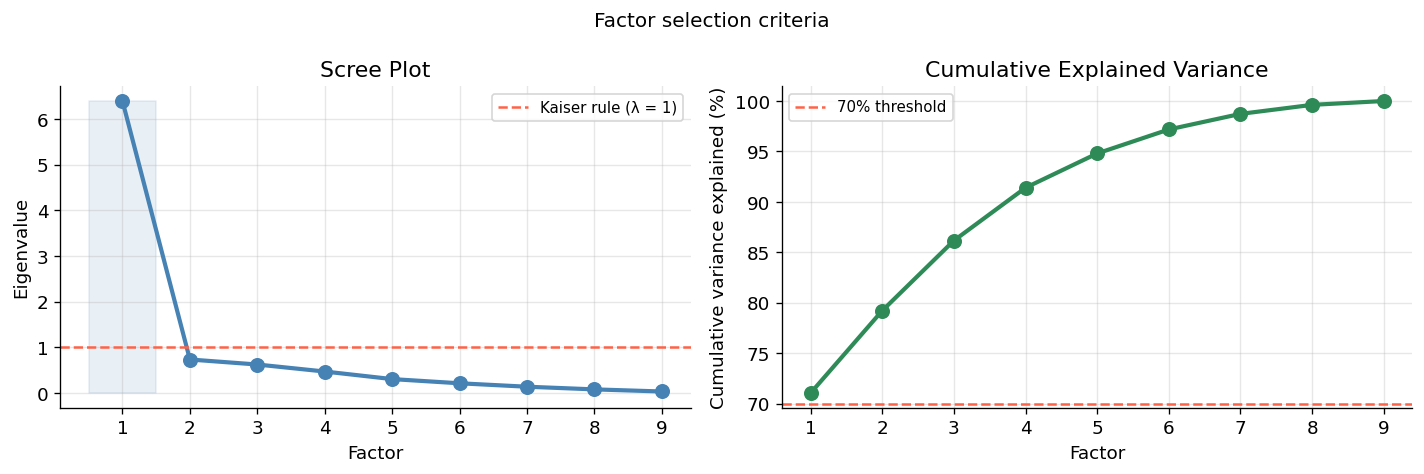

Eigenvalues and cumulative variance:
  Factor 1: λ = 6.3950  |  Cumulative = 71.1% ← Kaiser cutoff
  Factor 2: λ = 0.7349  |  Cumulative = 79.2%
  Factor 3: λ = 0.6249  |  Cumulative = 86.2%
  Factor 4: λ = 0.4715  |  Cumulative = 91.4%
  Factor 5: λ = 0.3058  |  Cumulative = 94.8%
  Factor 6: λ = 0.2141  |  Cumulative = 97.2%
  Factor 7: λ = 0.1389  |  Cumulative = 98.7%
  Factor 8: λ = 0.0805  |  Cumulative = 99.6%
  Factor 9: λ = 0.0344  |  Cumulative = 100.0%


In [7]:
corr_matrix = np.corrcoef(X.T)
eigenvalues = np.linalg.eigvalsh(corr_matrix)[::-1]
cumulative_var = np.cumsum(eigenvalues) / eigenvalues.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
axes[0].plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-',
             color='steelblue', linewidth=2.5, markersize=8)
axes[0].axhline(1, color='tomato', linestyle='--', linewidth=1.5, label='Kaiser rule (λ = 1)')
axes[0].fill_between([0.5, 1.5], [0, 0], [eigenvalues[0], eigenvalues[0]],
                     alpha=0.12, color='steelblue')
axes[0].set_xlabel('Factor')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Scree Plot')
axes[0].legend(fontsize=9)
axes[0].set_xticks(range(1, len(eigenvalues)+1))
axes[0].grid(True, alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, len(eigenvalues)+1), cumulative_var * 100, 'o-',
             color='seagreen', linewidth=2.5, markersize=8)
axes[1].axhline(70, color='tomato', linestyle='--', linewidth=1.5, label='70% threshold')
axes[1].set_xlabel('Factor')
axes[1].set_ylabel('Cumulative variance explained (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(1, len(eigenvalues)+1))
axes[1].grid(True, alpha=0.3)

plt.suptitle('Factor selection criteria', fontsize=12)
plt.tight_layout()
plt.savefig('fa_scree.png', bbox_inches='tight', dpi=150)
plt.show()

print("Eigenvalues and cumulative variance:")
for i, (ev, cv) in enumerate(zip(eigenvalues, cumulative_var)):
    marker = " ← Kaiser cutoff" if i == 0 and eigenvalues[1] < 1 else ""
    print(f"  Factor {i+1}: λ = {ev:.4f}  |  Cumulative = {cv*100:.1f}%{marker}")

The result is unusually clear: **Factor 1 has an eigenvalue of 6.39**, explaining
**71% of total variance** — and the second eigenvalue drops to 0.73, which is *below* the
Kaiser threshold of 1. The elbow at Factor 1 is unambiguous.

A single dominant factor with this much explanatory power is a strong signal that these nine
indicators are measuring essentially *one underlying thing*: a general axis of marginalization
that runs from structural deprivation to relative prosperity.

## Extracting the Factor: The Marginalization Index

We fit a 1-factor model using the **Principal Axis** method. For each variable, we get:

- **Loading**: correlation between the variable and the latent factor (0 to 1 in absolute value)
- **Communality**: proportion of the variable's variance explained by the factor (loading²)

A communality below 0.5 indicates the factor doesn't capture that variable well — the
variable has too much unique variance not shared with the others.

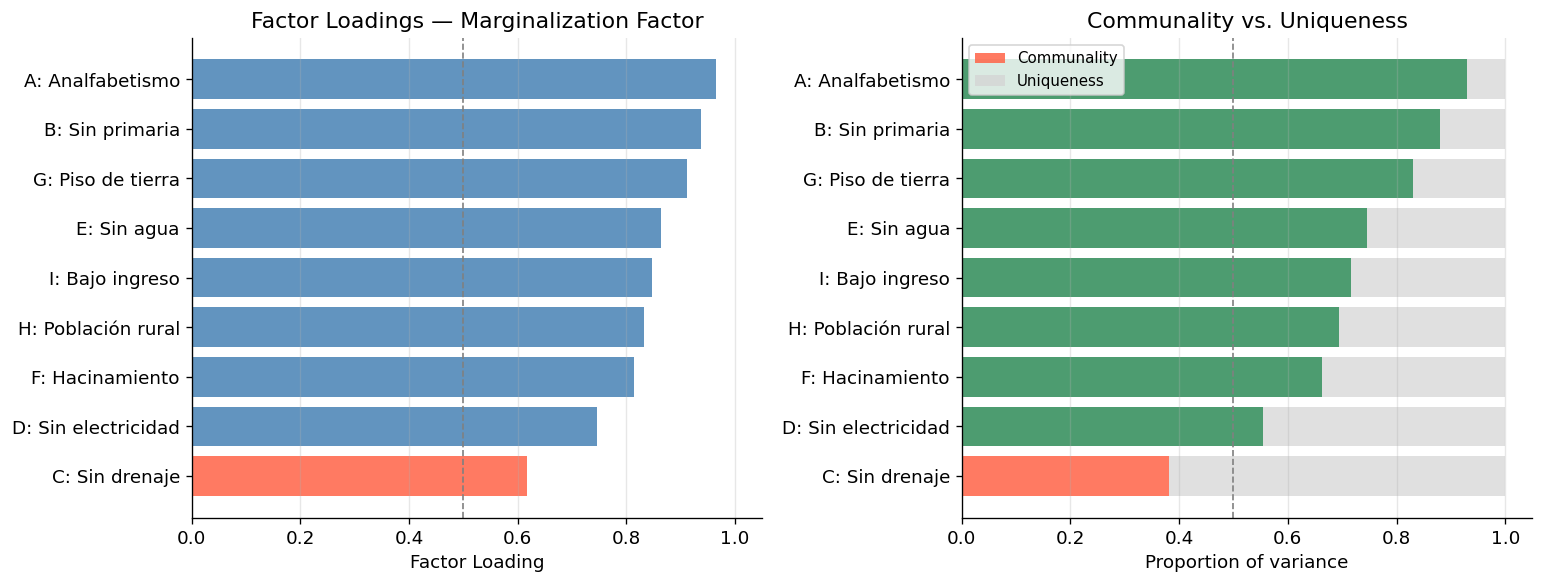

Factor explains 71.1% of total variance

           Variable  Loading  Communality
     C: Sin drenaje 0.617372     0.381148
D: Sin electricidad 0.745154     0.555254
    F: Hacinamiento 0.814310     0.663101
 H: Población rural 0.832753     0.693477
    I: Bajo ingreso 0.846557     0.716659
        E: Sin agua 0.863853     0.746242
  G: Piso de tierra 0.910983     0.829890
    B: Sin primaria 0.937820     0.879506
   A: Analfabetismo 0.964200     0.929682


In [8]:
fa = FactorAnalyzer(n_factors=1, rotation=None, method='principal')
fa.fit(X)

loadings = fa.loadings_.flatten()
communalities = fa.get_communalities()
uniqueness = 1 - communalities

fa_df = pd.DataFrame({
    'Variable'    : [f'{v}: {LABELS[v]}' for v in VARS],
    'Loading'     : loadings,
    'Communality' : communalities,
    'Uniqueness'  : uniqueness,
}).sort_values('Loading', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Loadings bar chart
colors_load = ['tomato' if c < 0.5 else 'steelblue' for c in fa_df['Communality']]
axes[0].barh(fa_df['Variable'], fa_df['Loading'], color=colors_load, alpha=0.85)
axes[0].axvline(0.5, color='grey', linestyle='--', linewidth=1)
axes[0].set_xlabel('Factor Loading')
axes[0].set_title('Factor Loadings — Marginalization Factor')
axes[0].set_xlim(0, 1.05)
axes[0].grid(True, alpha=0.3, axis='x')

# Communality chart
axes[1].barh(fa_df['Variable'], fa_df['Communality'],
             color=['tomato' if c < 0.5 else 'seagreen' for c in fa_df['Communality']],
             alpha=0.85, label='Communality')
axes[1].barh(fa_df['Variable'], fa_df['Uniqueness'],
             left=fa_df['Communality'], color='lightgrey', alpha=0.7, label='Uniqueness')
axes[1].axvline(0.5, color='grey', linestyle='--', linewidth=1)
axes[1].set_xlabel('Proportion of variance')
axes[1].set_title('Communality vs. Uniqueness')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1.05)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('fa_loadings.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Factor explains {fa.get_factor_variance()[2][0]*100:.1f}% of total variance\n")
print(fa_df[['Variable','Loading','Communality']].to_string(index=False))

**Reading the loadings:**

The three strongest loadings are **A (illiteracy, 0.96)**, **B (no primary school, 0.94)**,
and **G (dirt floors, 0.91)**. These are classic markers of extreme poverty — they load
heavily on the single factor because wherever illiteracy is high, dirt floors tend to be
high too, and vice versa.

**The exception: C (no sewage)** has a loading of only 0.62 and a communality of 0.38 —
well below 0.5. Sewage access in Mexico has a partially independent pattern from general
marginalization (it depends on municipal infrastructure investment and geography in ways
that other indicators don't), so the single-factor model captures it less well.

If we were to run a 2-factor model, C might load more cleanly on a separate
"infrastructure" factor alongside D and E.

## Factor Rotation: Varimax and Promax

With more than one factor, rotation helps make the factor structure more interpretable
by maximizing each variable's association with a single factor. There are two types:

- **Varimax** (orthogonal): factors remain uncorrelated — cleaner but assumes independence
- **Promax** (oblique): allows factors to correlate — more realistic for social data

**With only one factor, rotation has no effect** — there's nothing to rotate. We fit
both rotations for completeness and to illustrate that the loadings are identical,
which confirms the robustness of our 1-factor solution.

In [9]:
fa_varimax = FactorAnalyzer(n_factors=1, rotation='varimax', method='ml')
fa_varimax.fit(X)

fa_promax = FactorAnalyzer(n_factors=1, rotation='promax', method='ml')
fa_promax.fit(X)

comparison = pd.DataFrame({
    'Indicator'      : [f'{v}: {LABELS[v]}' for v in VARS],
    'No rotation'    : fa.loadings_.flatten().round(4),
    'Varimax'        : fa_varimax.loadings_.flatten().round(4),
    'Promax'         : fa_promax.loadings_.flatten().round(4),
})
print("Factor loadings under three rotation methods:")
print(comparison.to_string(index=False))
print()
print("Variance explained:")
print(f"  No rotation: {fa.get_factor_variance()[2][0]*100:.1f}%")
print(f"  Varimax:     {fa_varimax.get_factor_variance()[2][0]*100:.1f}%")
print(f"  Promax:      {fa_promax.get_factor_variance()[2][0]*100:.1f}%")
print()
print("Note: With a single factor, Varimax and Promax produce identical results.")
print("Rotation becomes meaningful only when there are 2 or more factors to reorient.")

Factor loadings under three rotation methods:
          Indicator  No rotation  Varimax  Promax
   A: Analfabetismo       0.9642   0.9895  0.9895
    B: Sin primaria       0.9378   0.9527  0.9527
     C: Sin drenaje       0.6174   0.5533  0.5533
D: Sin electricidad       0.7452   0.6538  0.6538
        E: Sin agua       0.8639   0.8364  0.8364
    F: Hacinamiento       0.8143   0.7865  0.7865
  G: Piso de tierra       0.9110   0.8971  0.8971
 H: Población rural       0.8328   0.8038  0.8038
    I: Bajo ingreso       0.8466   0.8263  0.8263

Variance explained:
  No rotation: 71.1%
  Varimax:     67.5%
  Promax:      67.5%

Note: With a single factor, Varimax and Promax produce identical results.
Rotation becomes meaningful only when there are 2 or more factors to reorient.


## Factor Scores: Ranking States by Marginalization

Factor scores are each state's position on the marginalization axis. They're computed
as a weighted combination of the standardized indicators, using the factor loadings as weights.

Positive scores = above-average marginalization; negative scores = below-average.

This is essentially what CONAPO's official marginalization index does — Factor Analysis
is the formal statistical foundation behind their published rankings.

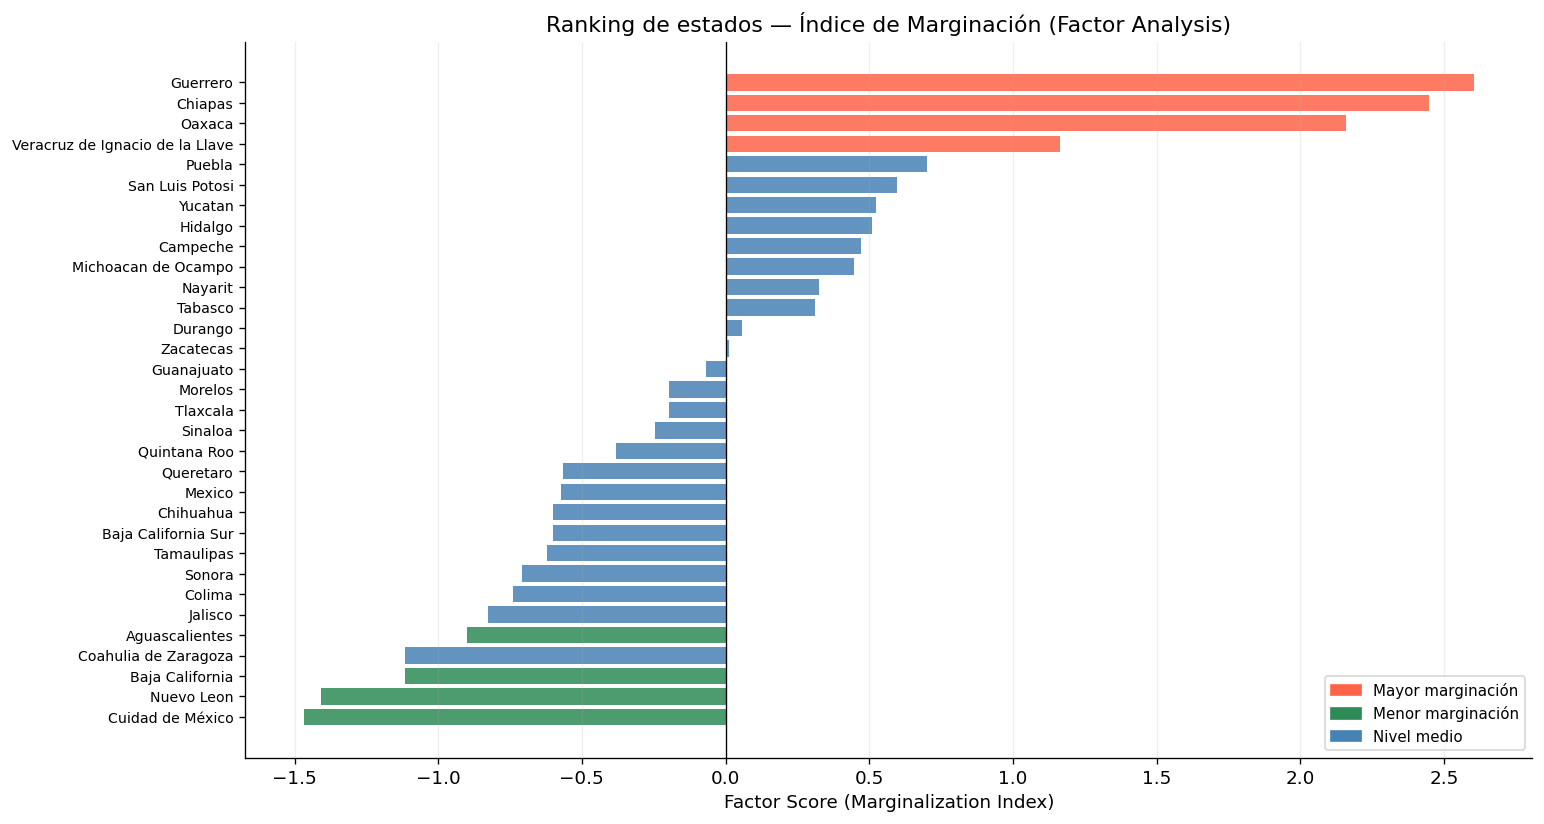

Top 5 más marginados:
 rank                          estado  marginacion
    1                        Guerrero     2.604554
    2                         Chiapas     2.447358
    3                          Oaxaca     2.159375
    4 Veracruz de Ignacio de la Llave     1.163514
    5                          Puebla     0.700652

Top 5 menos marginados:
 rank               estado  marginacion
   28       Aguascalientes    -0.899105
   29 Coahulia de Zaragoza    -1.113721
   30      Baja California    -1.114664
   31           Nuevo Leon    -1.407708
   32     Cuidad de México    -1.468085


In [10]:
scores = fa.transform(X)
score_df = pd.DataFrame({
    'estado'     : df['estado'],
    'marginacion': scores[:, 0],
}).sort_values('marginacion', ascending=False).reset_index(drop=True)

score_df['rank'] = score_df.index + 1

HIGHLIGHT_SCORES = {
    'Chiapas': 'tomato', 'Guerrero': 'tomato', 'Oaxaca': 'tomato',
    'Veracruz de Ignacio de la Llave': 'tomato',
    'Cuidad de México': 'seagreen', 'Nuevo Leon': 'seagreen',
    'Baja California': 'seagreen', 'Aguascalientes': 'seagreen',
}

colors_scores = [HIGHLIGHT_SCORES.get(s, 'steelblue') for s in score_df['estado']]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(score_df['estado'][::-1], score_df['marginacion'][::-1],
               color=colors_scores[::-1], alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Factor Score (Marginalization Index)')
ax.set_title('Ranking de estados — Índice de Marginación (Factor Analysis)')
ax.tick_params(axis='y', labelsize=8.5)
ax.grid(True, alpha=0.2, axis='x')

legend_elements = [
    mpatches.Patch(color='tomato',    label='Mayor marginación'),
    mpatches.Patch(color='seagreen',  label='Menor marginación'),
    mpatches.Patch(color='steelblue', label='Nivel medio'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('fa_scores.png', bbox_inches='tight', dpi=150)
plt.show()

print("Top 5 más marginados:")
print(score_df.head(5)[['rank','estado','marginacion']].to_string(index=False))
print()
print("Top 5 menos marginados:")
print(score_df.tail(5)[['rank','estado','marginacion']].to_string(index=False))

### Case study: Where should Guanajuato focus?

Looking at a specific state lets us translate factor analysis output into concrete policy
recommendations. Guanajuato sits near the middle of the ranking — not among the most
deprived, but with clear room for improvement.

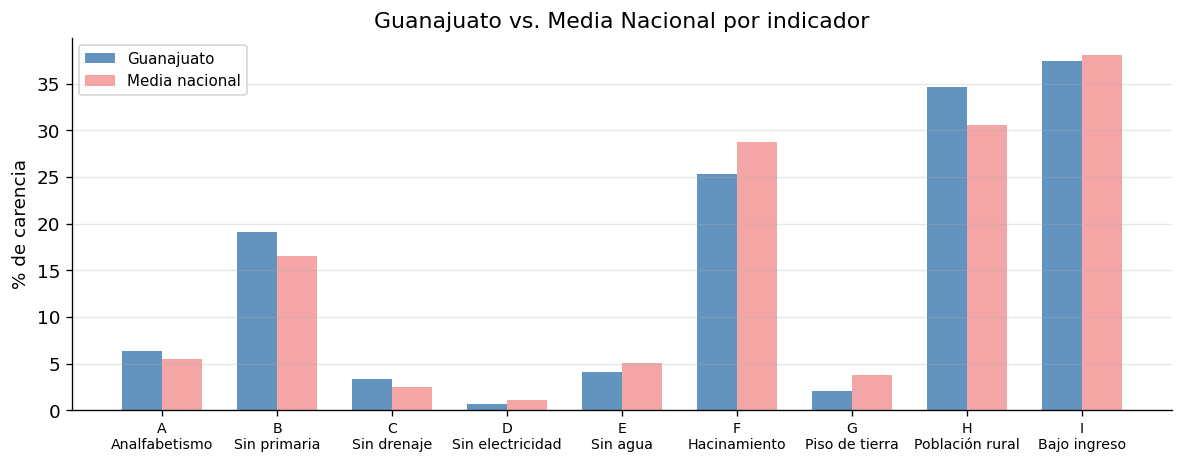

Guanajuato vs. national average:
       Indicator  Guanajuato  National avg  Difference Above avg?
   Analfabetismo        6.39          5.45        0.94    ▲ worse
    Sin primaria       19.12         16.55        2.57    ▲ worse
     Sin drenaje        3.31          2.47        0.84    ▲ worse
Sin electricidad        0.68          1.07       -0.39   ▼ better
        Sin agua        4.13          5.04       -0.91   ▼ better
    Hacinamiento       25.36         28.77       -3.41   ▼ better
  Piso de tierra        2.00          3.73       -1.73   ▼ better
 Población rural       34.67         30.61        4.06    ▲ worse
    Bajo ingreso       37.41         38.05       -0.64   ▼ better


In [11]:
gto = df[df['estado'].str.contains('Guanajuato')].copy()
gto_vals = gto[VARS].values.flatten()
national_mean = df[VARS].mean().values

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(VARS))
width = 0.35

bars1 = ax.bar(x - width/2, gto_vals, width, label='Guanajuato',
               color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, national_mean, width, label='Media nacional',
               color='lightcoral', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels([f'{v}\n{LABELS[v]}' for v in VARS], fontsize=8.5)
ax.set_ylabel('% de carencia')
ax.set_title('Guanajuato vs. Media Nacional por indicador')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Guanajuato vs. national average:")
comp = pd.DataFrame({'Indicator': [LABELS[v] for v in VARS],
                     'Guanajuato': gto_vals,
                     'National avg': national_mean,
                     'Difference': gto_vals - national_mean})
comp['Above avg?'] = comp['Difference'].apply(lambda x: '▲ worse' if x > 0 else '▼ better')
print(comp.round(2).to_string(index=False))

Guanajuato scores **above the national average on F (overcrowding) and I (low income)**
— and these also have high factor loadings, meaning they contribute significantly to the
marginalization index. Improving on these two dimensions would have the largest effect
on the state's composite score.

Indicator H (rural population) is also above average, but it's driven by demographic
structure rather than policy — rural-to-urban migration is slow to shift, and its factor
loading (0.83) reflects that it moves together with other deprivations rather than being
independently actionable.

## Conclusions

Factor Analysis extracted a single, powerful latent variable from nine CONAPO marginalization
indicators — and this factor accounts for **71% of the total variance** in the data.

**What the factor captures:** A general axis of structural poverty. States that score high
on illiteracy also tend to have dirt floors, lack running water, and earn low wages. These
conditions are so strongly correlated (driven by the same underlying socioeconomic forces)
that a single number — the marginalization score — summarizes them remarkably well.

**Key findings:**

- **Strongest indicators**: Illiteracy (A) and lack of primary schooling (B) are the variables
  most correlated with the latent factor — they're the most reliable "symptoms" of deep
  marginalization.
- **Weakest fit**: Sewage access (C) has a communality below 0.5, indicating it responds to
  different drivers (municipal infrastructure investment, geography) beyond general poverty.
- **Geographic persistence**: Chiapas, Guerrero, and Oaxaca sit far above the rest on the
  marginalization axis — a pattern visible in every individual indicator and confirmed by
  the composite score.
- **Rotation doesn't change the story**: With a single factor, Varimax and Promax produce
  identical loadings. Rotation becomes meaningful when there are 2+ factors to reorient
  for interpretability.

**PCA vs. Factor Analysis — when to use each:**

| | PCA | Factor Analysis |
|---|---|---|
| Goal | Reduce dimensions | Find latent structure |
| Maximizes | Total variance | Common variance |
| Best for | Compression, visualization | Theory-driven latent variables |
| Output | Components (linear combinations) | Factors (latent constructs) |

The full code and data are available at:
[github.com/ivandeluna/data-science-notebooks](https://github.com/ivandeluna/data-science-notebooks) — folder `08-metodos-multivariados/`